In [6]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("../data/processed/telco_cleaned.csv")

In [30]:
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Years
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 Years
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Years
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 Years
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Years


In [31]:
df['TotalCharges'].isnull().sum()

0

## Feature 1 — TenureGroup

In [32]:
#Step 1 — Inspect Tenure
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [33]:
df["TenureGroup"].unique()

array(['0-1 Years', '2-4 Years', '1-2 Years', '4-6 Years'], dtype=object)

In [34]:
df['TenureGroup'] = df["TenureGroup"].replace({
    '0-1 Years':'New Customers',
    '4-6 Years':'Loyal Customers'
})

In [35]:
df["TenureGroup"].unique()

array(['New Customers', '2-4 Years', '1-2 Years', 'Loyal Customers'],
      dtype=object)

In [36]:
pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize= "index"
) * 100

Churn,No,Yes
TenureGroup,,
1-2 Years,71.289062,28.710938
2-4 Years,79.611041,20.388959
Loyal Customers,90.486824,9.513176
New Customers,52.561757,47.438243


### Feature 2 - TotalServices

In [40]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [44]:
for col in service_columns:
    print(df[col].unique())

['No' 'Yes']
['No phone service' 'No' 'Yes']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']


In [49]:
for col in service_columns:
    service_df = df[service_columns].replace({
        'No':0,
        'No phone service': 0,
        'No internet service': 0,
        'Yes': 1,
        'DSL': 1,
        'Fiber optic':1
    })
service_df

,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0,0,1,0,1,0,0,0,0
1,1,0,1,1,0,1,0,0,0
2,1,0,1,1,1,0,0,0,0
3,0,0,1,1,0,1,1,0,0
4,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
7038,1,1,1,1,0,1,1,1,1
7039,1,1,1,0,1,1,0,1,1
7040,0,0,1,1,0,0,0,0,0
7041,1,1,1,0,0,0,0,0,0


In [52]:
df["TotalServices"] = service_df.sum(axis=1)

In [53]:
df['TotalServices'].describe()

count    7043.000000
mean        4.146244
std         2.312720
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: TotalServices, dtype: float64

In [58]:
df['TotalServices'].value_counts().sort_index()

1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: TotalServices, dtype: int64

In [59]:
pd.crosstab(
    df['TotalServices'],
    df['Churn'],
    normalize=True
)*100

Churn,No,Yes
TotalServices,,
1,15.987505,1.959392
2,8.419708,3.776800
3,6.616499,5.395428
4,8.703677,4.997870
5,8.987647,4.103365
6,9.598183,3.294051
7,7.440011,2.158171
8,4.912679,0.695726
9,2.797104,0.156183


<Axes: xlabel='TotalServices'>

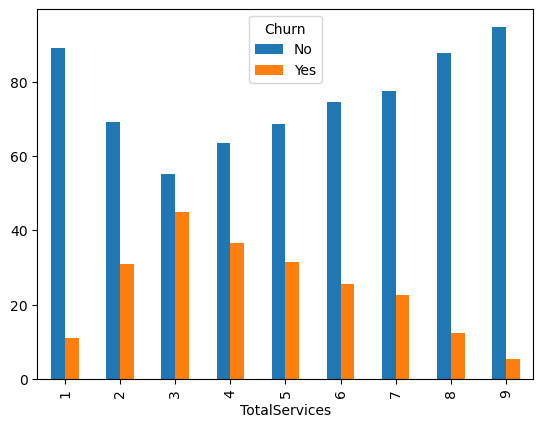

In [63]:
(pd.crosstab(
    df['TotalServices'],
    df['Churn'],
    normalize= "index"
) * 100).plot(kind = "bar")

#### Customers subscribing to a greater number of services generally exhibit lower churn rates compared to customers with fewer services. This suggests that customers who are more engaged with the company's offerings are more likely to remain loyal. The engineered feature TotalServices captures overall customer engagement and may improve churn prediction models.

In [66]:
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,TotalServices
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New Customers,2
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 Years,4
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New Customers,4
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 Years,4
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New Customers,2


### FEATURE 03- HasSecurityBundle

In [67]:
SecurityBundle = ['OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport']

In [68]:
for col in SecurityBundle:
    print(df[col].unique())

['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']


In [69]:
for col in SecurityBundle:
    Security_df = df[SecurityBundle].replace({
        'No':0,
        'No internet service':0,
        'Yes':1
    })
Security_df

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport
0,0,1,0,0
1,1,0,1,0
2,1,1,0,0
3,1,0,1,1
4,0,0,0,0
...,...,...,...,...
7038,1,0,1,1
7039,0,1,1,0
7040,1,0,0,0
7041,0,0,0,0


In [70]:
df["HasSecurityBundle"] = Security_df.sum(axis=1)

In [71]:
df["HasSecurityBundle"].describe()

count    7043.000000
mean        1.265654
std         1.286879
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: HasSecurityBundle, dtype: float64

In [72]:
pd.crosstab(
    df['HasSecurityBundle'],
    df['Churn'],
    normalize='index'
)* 100

Churn,No,Yes
HasSecurityBundle,,
0,70.247046,29.752954
1,61.145194,38.854806
2,76.239067,23.760933
3,87.566419,12.433581
4,94.680851,5.319149


<Axes: xlabel='HasSecurityBundle'>

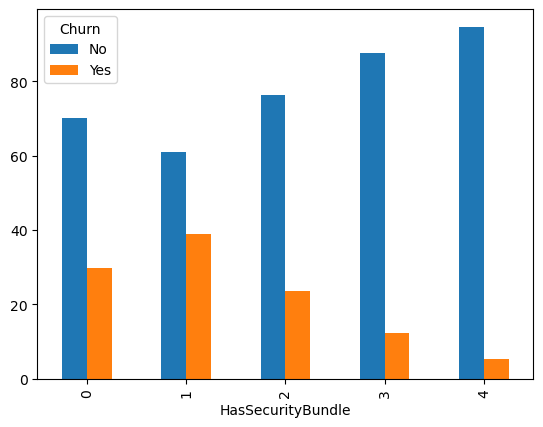

In [73]:
(pd.crosstab(
    df['HasSecurityBundle'],
    df['Churn'],
    normalize='index'
)* 100).plot(kind = "bar")

#### Customers who subscribe to multiple security-related services exhibit significantly lower churn rates. This suggests that customers investing in security and support features are more engaged with the company's ecosystem and are less likely to leave. The HasSecurityBundle feature captures this engagement and is expected to improve churn prediction performance.

### Feature 4 — AverageMonthlySpend

In [74]:
df["AverageMonthlySpend"] = np.where(
    df['tenure'] == 0,
    df['TotalCharges'],
    df['TotalCharges']/df['tenure']
)

In [78]:
df['AverageMonthlySpend'].describe()

count    7043.000000
mean       64.698218
std        30.270670
min         0.000000
25%        35.649000
50%        70.300000
75%        90.174158
max       121.400000
Name: AverageMonthlySpend, dtype: float64

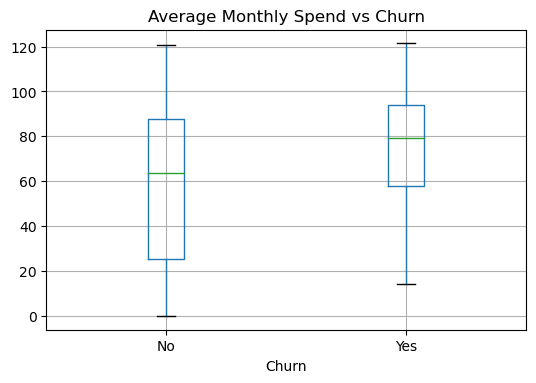

In [79]:
df.boxplot(
    column="AverageMonthlySpend",
    by="Churn",
    figsize=(6,4)
)

plt.title("Average Monthly Spend vs Churn")
plt.suptitle("")
plt.show()

### Feature 5 — FamilyCustomer

In [80]:
FamilyCustomer = ['Partner','Dependents']

In [94]:
IsFamilyCustomer = df[FamilyCustomer].replace({
    'No':0,
    'Yes':1
})

IsFamilyCustomer

,Partner,Dependents
0,1,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
7038,1,1
7039,1,1
7040,1,1
7041,1,0


In [95]:
df['IsFamilyCustomer'] = IsFamilyCustomer.any(axis=1).astype(int)

In [98]:
df['IsFamilyCustomer'].describe()

count    7043.000000
mean        0.534289
std         0.498858
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: IsFamilyCustomer, dtype: float64

<Axes: xlabel='IsFamilyCustomer'>

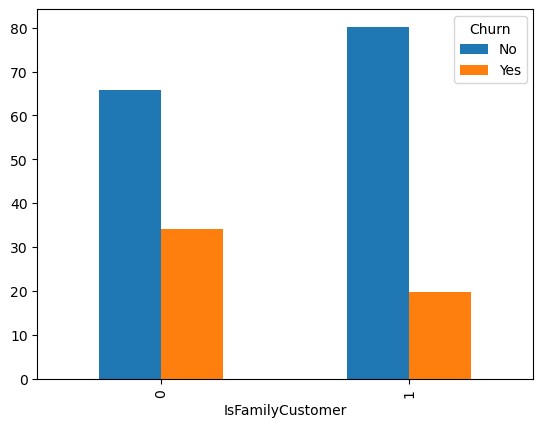

In [100]:
(pd.crosstab(
    df['IsFamilyCustomer'],
    df['Churn'],
    normalize='index'
)* 100).plot(kind = "bar")

#### Customers with partners or dependents are generally more stable customers and exhibit lower churn rates. The IsFamilyCustomer feature captures household commitment, which may contribute positively to churn prediction.

In [101]:
df.to_csv("../data/featured/telco_feature_engineered.csv")